In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [2]:
import pandas as pd
import numpy as np

In [3]:
results_df = pd.read_csv('output/region_runs/summary_species.csv')

In [4]:
results_df.fillna(0, inplace=True)

In [5]:
results_df.groupby(['region', 'model_type', 'group'])['auc'].mean().groupby(['model_type', 'region']).mean()

model_type      region
PO_Only_Smooth  AWT       0.706693
                CAN       0.733827
                NSW       0.736928
                NZ        0.752683
                SA        0.793437
                SWI       0.841753
Name: auc, dtype: float64

In [6]:
results_df.groupby(['region', 'model_type', 'group'])['auc'].mean().groupby(['model_type', 'region']).mean().groupby(['model_type']).mean()

model_type
PO_Only_Smooth    0.760887
Name: auc, dtype: float64

In [7]:
avg_region = results_df.groupby(['region', 'model_type'])['auc'].mean()

total_avg = avg_region.groupby(['model_type']).mean()

print(total_avg)

model_type
PO_Only_Smooth    0.758137
Name: auc, dtype: float64


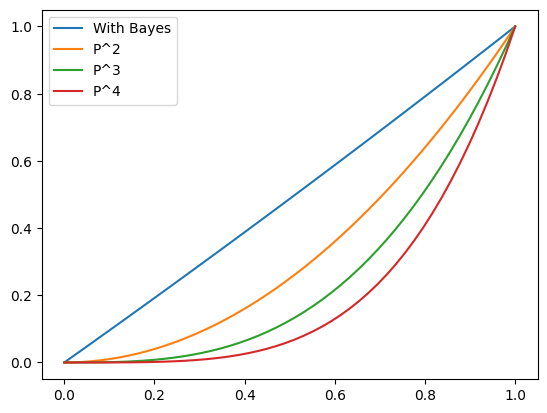

In [14]:
import matplotlib.pyplot as plt

theta = 0.95

p = np.linspace(0, 1, 50)
plt.plot(p, p*(theta)/(1 - p + p*(theta)), label=f'With Bayes')
## plot the square
plt.plot(p, p**2, label='P^2')
plt.plot(p, p**3, label='P^3')
plt.plot(p, p**4, label='P^4')
# plt.plot(p, p*(1-theta), label='no smoothing')
plt.legend()